# ML Project - KNN Loan Applicant Credit Risk Analysis

# Part-1: Data Exploration and Pre-processing


# 1) load the given dataset

In [2]:
import pandas as pd 

In [3]:
data = pd.read_excel(r"C:\Users\nisth\Downloads\ML PROJECTS\ML PROJECT CSV DATASET\1768299714153-ML Project - KNN Loan Applicant Credit Risk Analysis U 16955473070.xlsx")

In [4]:
data.head()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


# 2) Check for the null values

In [6]:
data.isnull().any()

Age                           False
Total Work Experience         False
Number of years in city       False
Cost to Request Ratio         False
Cibil score                   False
Overdrafts past12months       False
Total bounces past12months    False
dtype: bool

In [7]:
data.isnull().sum()

Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64

# 3) Get basic information from data

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


In [9]:
data.dtypes

Age                           float64
Total Work Experience           int64
Number of years in city         int64
Cost to Request Ratio         float64
Cibil score                     int64
Overdrafts past12months         int64
Total bounces past12months      int64
dtype: object

# 4) Describe the dataset

In [10]:
data.describe()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
count,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,38.808202,2.131073,4.288160,0.831183,752.626570,0.322068,1.162757
std,10.203371,0.892141,1.269416,0.490216,67.645792,0.914998,2.352798
min,18.100000,1.000000,1.000000,0.008466,351.000000,0.000000,0.000000
25%,30.830000,1.000000,3.000000,0.662147,730.000000,0.000000,0.000000
50%,37.200000,2.000000,4.000000,0.800000,768.000000,0.000000,0.000000
75%,45.400000,3.000000,5.000000,0.930908,797.000000,0.000000,1.000000
max,83.800000,5.000000,6.000000,12.006623,882.000000,12.000000,12.000000


In [11]:
data.duplicated().sum()

17

In [12]:
data = data.drop_duplicates()

In [13]:
data.duplicated().sum()

0

# 5) Display scatterplot between age & Total work Experience

In [14]:
import matplotlib.pyplot as plt

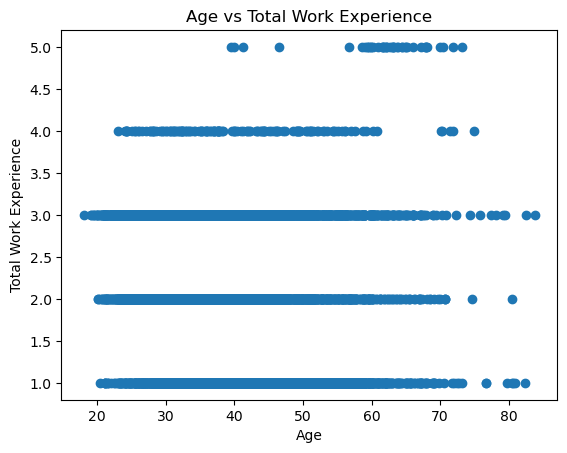

In [64]:
plt.scatter(data['Age'],data['Total Work Experience'])
plt.xlabel('Age')
plt.ylabel('Total Work Experience')
plt.title('Age vs Total Work Experience')

plt.show()

# 6) Display box plot for age

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

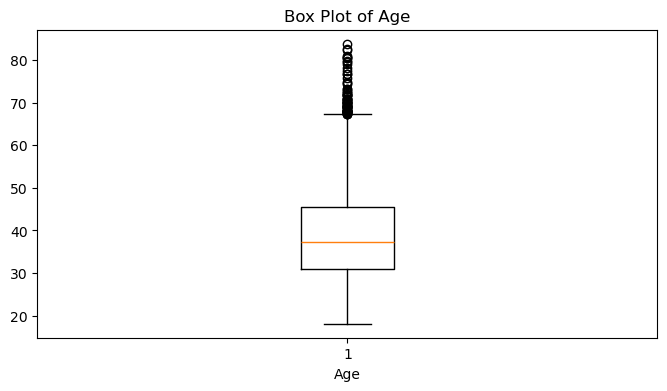

In [60]:
plt.figure(figsize=(8,4))
plt.boxplot(data['Age'])
plt.title('Box Plot of Age')
plt.xlabel('Age')

plt.show()

# 7) Display box plot for Cibil score

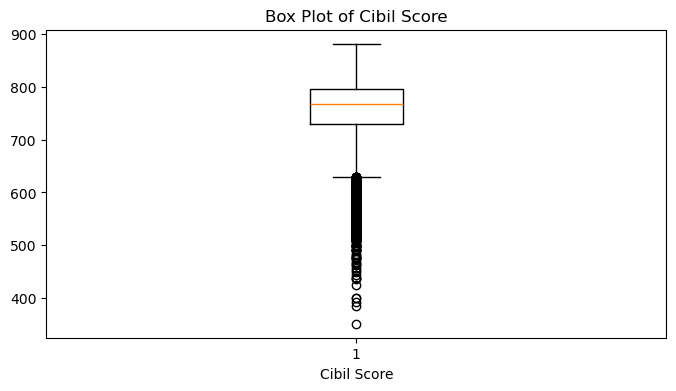

In [57]:
plt.figure(figsize=(8,4))
plt.boxplot(data['Cibil score'])
plt.title('Box Plot of Cibil Score')
plt.xlabel('Cibil Score')

plt.show()

# Part-2: Working with Model

# 1) Create target and features data where target is Total bounces past 12 months

In [19]:
x = data.drop('Total bounces past12months' , axis = 1)
y = data['Total bounces past12months']

In [20]:
x.head()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months
0,40.50,2,6,0.842666,594,0
1,41.25,5,2,0.791667,754,0
2,39.50,5,2,0.727273,779,0
3,35.00,1,4,0.820232,818,0
4,34.00,3,3,0.455581,853,0


In [21]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: Total bounces past12months, dtype: int64

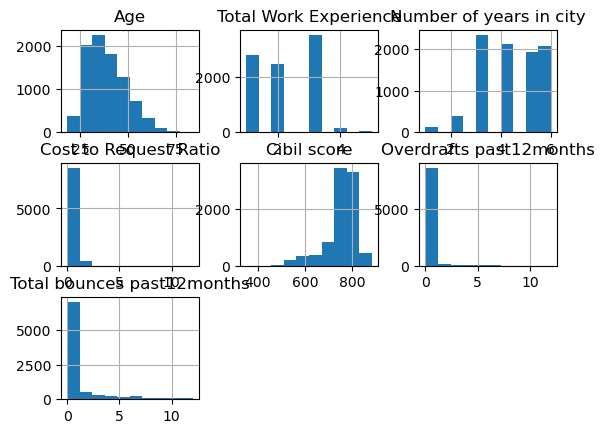

In [22]:
data.hist();

# 2) Split data into training and testing sets

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x , y , train_size = 0.8 , random_state = 47)

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
x = pd.DataFrame(scaler.fit_transform(x) , columns = x.columns)

In [28]:
x

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months
0,0.166102,-0.145648,1.348953,0.023164,-2.348652,-0.352381
1,0.239602,3.218736,-1.802260,-0.080793,0.019240,-0.352381
2,0.068102,3.218736,-1.802260,-0.212055,0.389223,-0.352381
3,-0.372898,-1.267109,-0.226654,-0.022564,0.966397,-0.352381
4,-0.470899,0.975814,-1.014457,-0.765877,1.484373,-0.352381
...,...,...,...,...,...,...
8973,-0.784499,0.975814,-1.014457,-0.478120,0.152434,-0.352381
8974,-0.683559,0.975814,1.348953,0.316957,-3.266210,-0.352381
8975,-0.601239,-0.145648,0.561150,-0.413743,-2.407849,-0.352381
8976,-0.176898,0.975814,-1.014457,-0.069527,0.877601,-0.352381


# 3) Create a KNN classifier between Features and target data

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
model = KNeighborsClassifier(20)

In [31]:
model.fit(x_train , y_train)

KNeighborsClassifier(n_neighbors=20)

# 4) Display the training score

In [32]:
model.score(x_train , y_train)

0.657198551935394

# 5) Display the test score

In [33]:
model.score(x_test,y_test)

0.6403118040089086

# 6) Print the accuracy score

In [34]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [35]:
y_pred = model.predict(x_test)

In [36]:
accuracy_score(y_test , y_pred)

0.6403118040089086

In [37]:
confusion_matrix(y_test , y_pred)

array([[1145,    7,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [ 249,    5,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [ 104,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  65,    3,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  37,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  34,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  27,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  36,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  15,    0,    0,    0,    0,    1,    0,    0,    0,    0,    0,
           0,    0],
       [  17,    0,    1,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0],
       [  17,    0,    0,    0,    0,    0,    0, 

In [38]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.65      0.99      0.78      1152
           1       0.28      0.02      0.04       254
           2       0.00      0.00      0.00       106
           3       0.00      0.00      0.00        68
           4       0.00      0.00      0.00        37
           5       0.00      0.00      0.00        34
           6       0.00      0.00      0.00        27
           7       0.00      0.00      0.00        36
           8       0.00      0.00      0.00        16
           9       0.00      0.00      0.00        18
          10       0.00      0.00      0.00        17
          11       0.00      0.00      0.00        22
          12       0.00      0.00      0.00         9

    accuracy                           0.64      1796
   macro avg       0.07      0.08      0.06      1796
weighted avg       0.45      0.64      0.51      1796



C:\Users\nisth\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nisth\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nisth\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
import warnings
warnings.filterwarnings('ignore')

# 7) Try 1 to 14 k values for classifier

In [40]:
from sklearn.neighbors import KNeighborsClassifier
training_acc = []
testing_acc = []

for i in range(1 , 15):
    model = KNeighborsClassifier(i)
    model.fit(x_train , y_train)
    training_acc.append(model.score(x_train , y_train))
    testing_acc.append(model.score(x_test,y_test))

In [41]:
import matplotlib.pyplot as plt

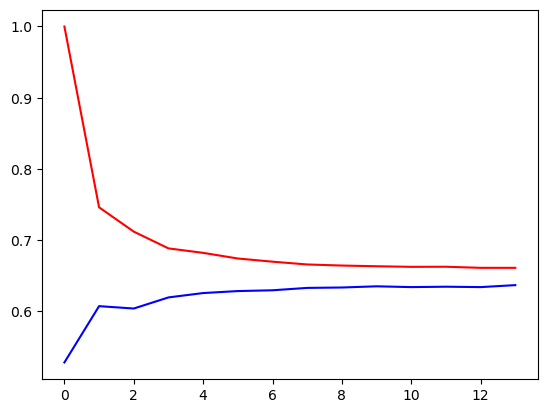

In [42]:
plt.plot(training_acc , color = "r")
plt.plot(testing_acc , color = "b");

# 8) Display training and testing score for all the 1 to 14 k values

In [43]:
results = pd.DataFrame({
    'K Value': range(1, 15),
    'Training Score': training_acc,
    'Testing Score':  testing_acc
})

results

,K Value,Training Score,Testing Score
0,1,1.000000,0.528396
1,2,0.746171,0.607461
2,3,0.712058,0.604120
3,4,0.688527,0.619710
4,5,0.682261,0.625835
5,6,0.674325,0.628619
6,7,0.669869,0.629733
7,8,0.665970,0.633073
8,9,0.664439,0.633630
9,10,0.663464,0.635301


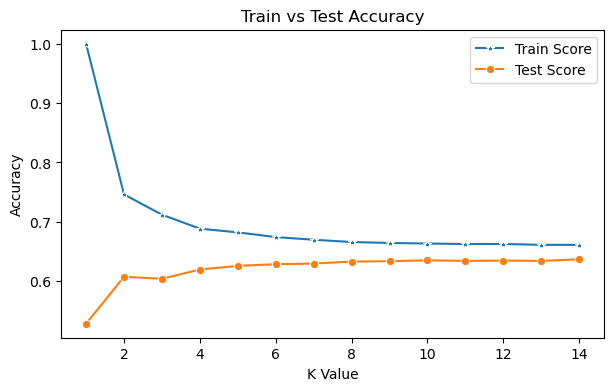

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
p = sns.lineplot(x=range(1,15),y=training_acc,marker='*',label='Train Score')
p = sns.lineplot(x=range(1,15),y=testing_acc,marker='o',label='Test Score')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()